# ETL

In [39]:
import pandas as pd 
df_drift = pd.read_csv('data/drifting_longlines_silver.csv')
df_drift.shape

(206700, 10)

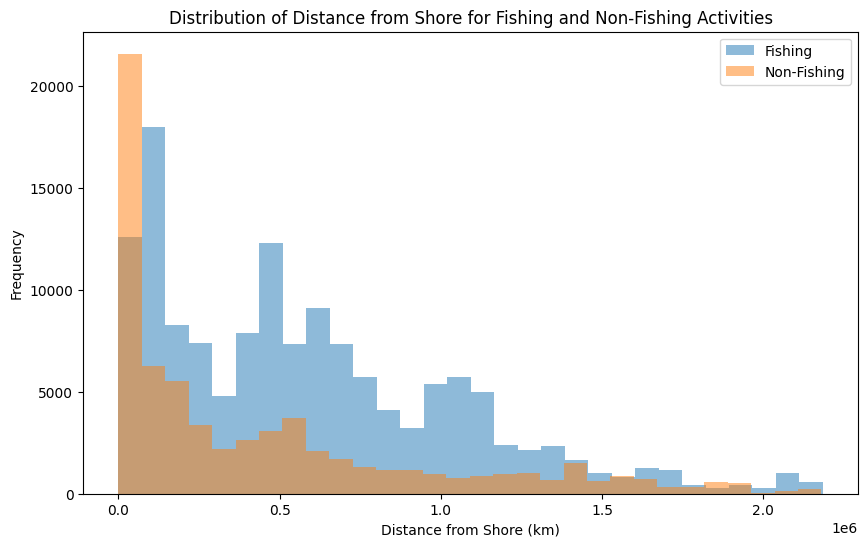

In [40]:
# plotting the distribution of the distance from shore for fishing and non-fishing activities
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df_drift[df_drift['is_fishing'] == 1]['distance_from_shore'], bins=30, alpha=0.5, label='Fishing')
plt.hist(df_drift[df_drift['is_fishing'] == 0]['distance_from_shore'], bins=30, alpha=0.5, label='Non-Fishing')
plt.xlabel('Distance from Shore (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distance from Shore for Fishing and Non-Fishing Activities')
plt.legend()
plt.show()

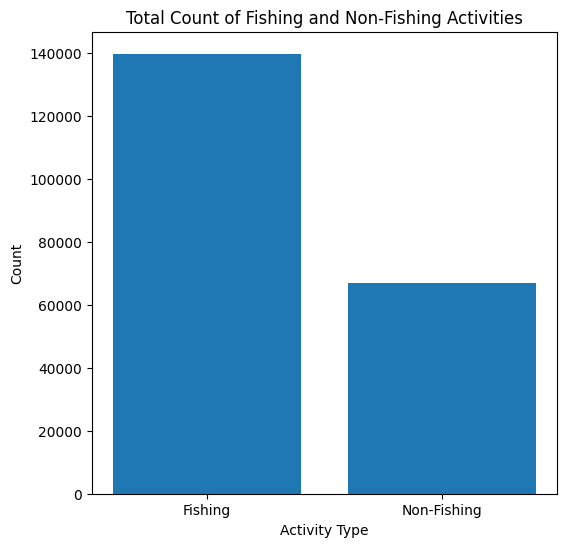

In [41]:
# plot total de fishing and non-fishing activities
plt.figure(figsize=(6, 6))
counts = df_drift['is_fishing'].value_counts().reindex([1.0, 0.0], fill_value=0)
plt.bar(['Fishing', 'Non-Fishing'], counts.values)
plt.xlabel('Activity Type')
plt.ylabel('Count')
plt.title('Total Count of Fishing and Non-Fishing Activities')
plt.show()

In [42]:
# down sample fishing activities to balance the dataset
fishing_df = df_drift[df_drift['is_fishing'] == 1]
non_fishing_df = df_drift[df_drift['is_fishing'] == 0]
fishing_sampled = fishing_df.sample(n=len(non_fishing_df), random_state=42)
df_drift = pd.concat([fishing_sampled, non_fishing_df]).sample(frac=1, random_state=42).reset_index(drop=True)
df_drift.shape


(133708, 10)

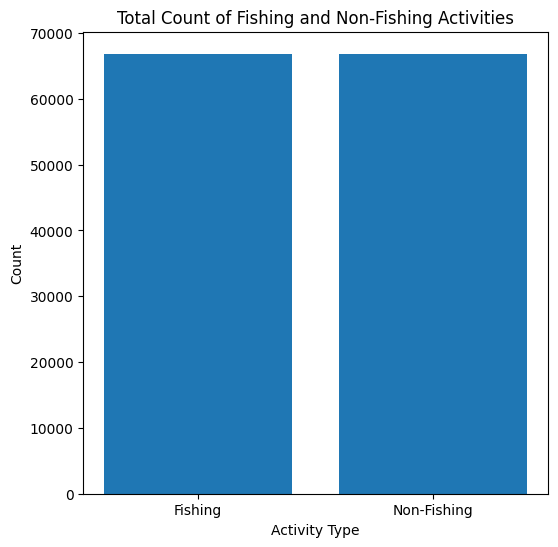

In [43]:
# plot total de fishing and non-fishing activities
plt.figure(figsize=(6, 6))
counts = df_drift['is_fishing'].value_counts().reindex([1.0, 0.0], fill_value=0)
plt.bar(['Fishing', 'Non-Fishing'], counts.values)
plt.xlabel('Activity Type')
plt.ylabel('Count')
plt.title('Total Count of Fishing and Non-Fishing Activities')
plt.show()

# Data transformation

In [44]:
# ! pip install scikit-learn

In [47]:

# criar coluna dia e coluna mes
df_drift['timestamp'] = pd.to_datetime(df_drift['timestamp'])

df_drift['month'] = df_drift['timestamp'].dt.month
df_drift['day'] = df_drift['timestamp'].dt.day
model_data = df_drift.drop(columns=['mmsi',"source", 'timestamp'])
# data split
from sklearn.model_selection import train_test_split

X = model_data.drop(columns=['is_fishing'])
y = model_data['is_fishing']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df_drift['mmsi'])


# data train normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




# Train

In [48]:
# treinar com multiplos modelos de classificação min 10 modelos de classificação e comparar os resultados
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import average_precision_score

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'Bagging': BaggingClassifier(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    average_precision = average_precision_score(y_test, y_proba)
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'roc_auc_score': roc_auc,
        'average_precision_score': average_precision
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}, Average Precision: {average_precision:.4f}")
results_df = pd.DataFrame(results).T
results_df.sort_values(by='accuracy', ascending=False)

Logistic Regression - Accuracy: 0.6621, Precision: 0.6676, Recall: 0.6598, F1-Score: 0.6637, ROC AUC: 0.7316, Average Precision: 0.7373
Random Forest - Accuracy: 0.9908, Precision: 0.9882, Recall: 0.9937, F1-Score: 0.9910, ROC AUC: 0.9994, Average Precision: 0.9994
SVM - Accuracy: 0.8667, Precision: 0.8747, Recall: 0.8594, F1-Score: 0.8670, ROC AUC: 0.9382, Average Precision: 0.9345
KNN - Accuracy: 0.9730, Precision: 0.9752, Recall: 0.9713, F1-Score: 0.9732, ROC AUC: 0.9923, Average Precision: 0.9886
Naive Bayes - Accuracy: 0.7060, Precision: 0.7393, Recall: 0.6458, F1-Score: 0.6894, ROC AUC: 0.7830, Average Precision: 0.7957
Decision Tree - Accuracy: 0.9798, Precision: 0.9804, Recall: 0.9797, F1-Score: 0.9800, ROC AUC: 0.9798, Average Precision: 0.9707
Gradient Boosting - Accuracy: 0.8489, Precision: 0.8583, Recall: 0.8397, F1-Score: 0.8489, ROC AUC: 0.9346, Average Precision: 0.9337
AdaBoost - Accuracy: 0.7754, Precision: 0.8273, Recall: 0.7021, F1-Score: 0.7596, ROC AUC: 0.8725, Ave

,accuracy,precision,recall,f1-score,roc_auc_score,average_precision_score
Extra Trees,0.993419,0.990873,0.996152,0.993506,0.999640,0.999561
Random Forest,0.990838,0.988226,0.993710,0.990960,0.999389,0.999354
Bagging,0.987361,0.987928,0.987050,0.987489,0.997279,0.995681
Decision Tree,0.979807,0.980376,0.979651,0.980013,0.979809,0.970710
KNN,0.973001,0.975186,0.971289,0.973233,0.992299,0.988590
SVM,0.866726,0.874680,0.859405,0.866975,0.938238,0.934493
Gradient Boosting,0.848927,0.858267,0.839722,0.848893,0.934650,0.933692
AdaBoost,0.775372,0.827274,0.702087,0.759556,0.872522,0.864780
Naive Bayes,0.705968,0.739348,0.645849,0.689443,0.783047,0.795669
Logistic Regression,0.662105,0.667640,0.659834,0.663714,0.731598,0.737322


In [9]:
# ! pip install seaborn

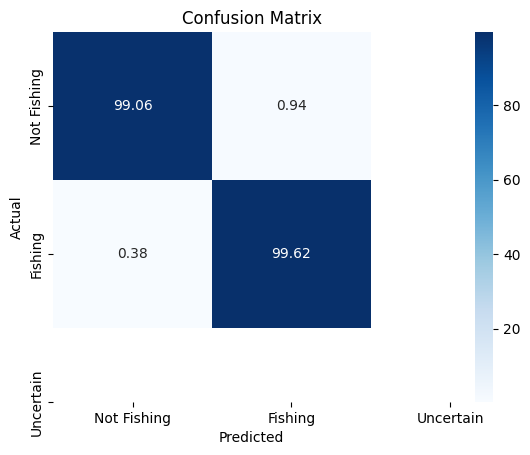

In [56]:
# plotting confusion matrix for the best model
import seaborn as sns
import numpy as np
best_model = results_df.sort_values(by='accuracy', ascending=False).index[0]
selct_model = models[best_model]


# plot for test set
y_true = y_test
y_pred = selct_model.predict(X_test_scaled)
import matplotlib.pyplot as plt

# plot percentage of true positives, true negatives, false positives and false negatives
cm = confusion_matrix(y_true, y_pred)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Not Fishing', 'Fishing', 'Uncertain'], yticklabels=['Not Fishing', 'Fishing', 'Uncertain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
import pandas as pd 
df_drift = pd.read_csv('data/drifting_longlines.csv')
df_drift = df_drift.drop_duplicates(subset=['mmsi', 'timestamp', 'distance_from_shore', 'distance_from_port',
       'speed', 'course', 'lat', 'lon', 'is_fishing'])
df_drift['new_class'] = selct_model.predict(scaler.transform(df_drift.drop(columns=['mmsi', 'timestamp', 'is_fishing', "source",])))
df_drift['new_class_score'] = selct_model.predict_proba(scaler.transform(df_drift.drop(columns=['mmsi', 'timestamp', 'is_fishing', "source",'new_class'])))[:, 1]
df_drift['timestamp'] = pd.to_datetime(df_drift['timestamp'], unit='s')



In [14]:
only_new = df_drift[df_drift['is_fishing'] != -1]
# round to 2 decimal places
only_new['new_class_score'] = only_new['new_class_score'].round(2)
# no cientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [15]:

# add 80% , 90% and 95% confidence intervals
only_new['new_class_score'].describe([0.25, 0.3, 0.35, 0.4, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99])
# only_new['new_class_score'].describe()

count   219741.00
mean         0.63
std          0.47
min          0.00
25%          0.00
30%          0.00
35%          0.03
40%          0.90
50%          0.99
75%          1.00
80%          1.00
90%          1.00
95%          1.00
99%          1.00
max          1.00
Name: new_class_score, dtype: float64

In [16]:
gb = df_drift.groupby('mmsi')

# pegar maior grupo
group_list = gb.size().sort_values(ascending=False)


# plot distance_from_shore and distance_from_port over time

import matplotlib.pyplot as plt
best_model = results_df.sort_values(by='accuracy', ascending=False).index[0]
selct_model = models[best_model]

# create 2 new columns with the predicted class and the score of the prediction
group = gb.get_group(group_list.index[0])


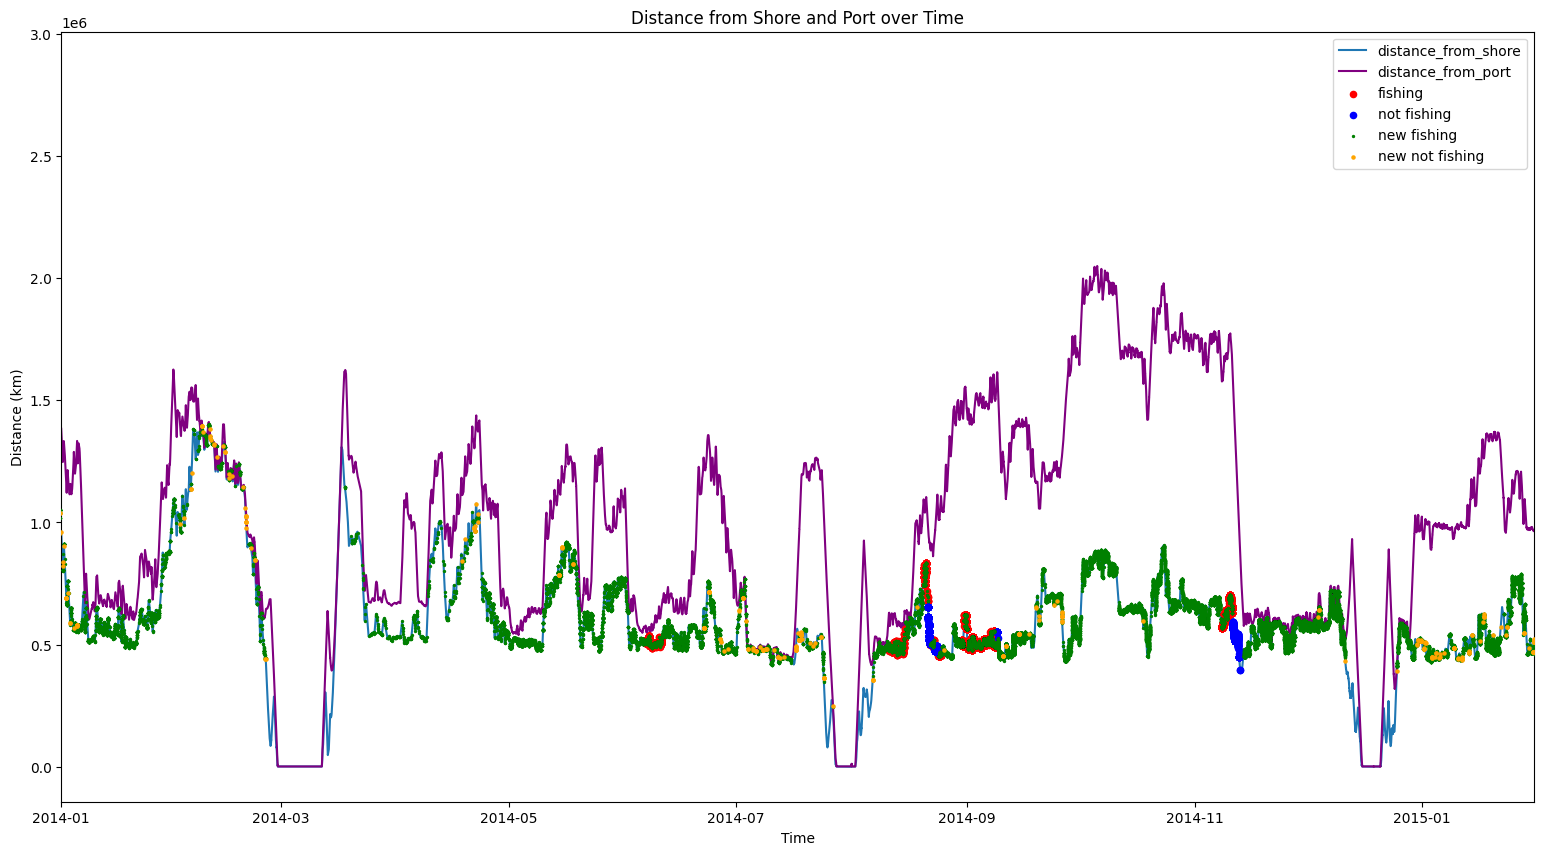

In [17]:
plt.figure(figsize=(19, 10))
plt.xlim(pd.Timestamp('2014-01-01'), pd.Timestamp('2015-01-31'))
plt.plot(group['timestamp'], group['distance_from_shore'], label='distance_from_shore')
plt.plot(group['timestamp'], group['distance_from_port'], label='distance_from_port', color='purple')
# adicionar pontos coloridos onde is_fishing
fishing_points = group[group['is_fishing'] > 0]
plt.scatter(fishing_points['timestamp'], fishing_points['distance_from_shore'], color='red', label='fishing', zorder=4, s=20)
not_fishing_points = group[group['is_fishing'] == 0]
plt.scatter(not_fishing_points['timestamp'], not_fishing_points['distance_from_shore'], color='blue', label='not fishing', zorder=4, s=20)

new_fishing_points = group[(group['new_class'] == 1) & (group['new_class_score'] >= 0.5)]
plt.scatter(new_fishing_points['timestamp'], new_fishing_points['distance_from_shore'], color='green', label='new fishing', zorder=4, s=2)
new_not_fishing_points = group[(group['new_class'] == 0) & (group['new_class_score'] >= 0.5)]
plt.scatter(new_not_fishing_points['timestamp'], new_not_fishing_points['distance_from_shore'], color='orange', label='new not fishing', zorder=4, s=5)


plt.legend()
plt.title('Distance from Shore and Port over Time')
plt.xlabel('Time')
plt.ylabel('Distance (km)')
plt.show()

In [18]:
# treinar somente com dados de velocidade e direção e movimento

In [19]:
# ! pip install shap

In [59]:
import shap
best_model_name = results_df['f1-score'].idxmax()
best_model = models[best_model_name]

In [60]:
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

In [61]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

In [62]:
print(f"Best model: {best_model_name}")
# explainer = shap.Explainer(best_model, X_train_scaled)
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(
    X_test_scaled,
    check_additivity=False
)

Best model: Extra Trees


In [63]:
print("X original:", X.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("features:", len(X.columns))
print(X.columns.tolist())

X original: (133708, 8)
X_train_scaled: (106966, 8)
X_test_scaled: (26742, 8)
features: 8
['distance_from_shore', 'distance_from_port', 'speed', 'course', 'lat', 'lon', 'month', 'day']


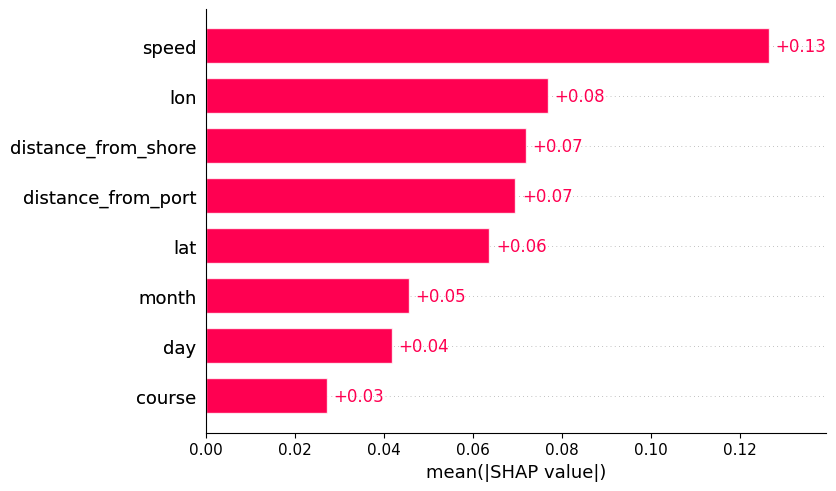

In [70]:
shap_values_class_1 = shap_values[:, :, 1]
shap.plots.bar(
    shap.Explanation(
        values=shap_values_class_1,
        base_values=explainer.expected_value[1],
        data=X_test_scaled_df.values,
        feature_names=X_test_scaled_df.columns
    ),
    max_display=8
)

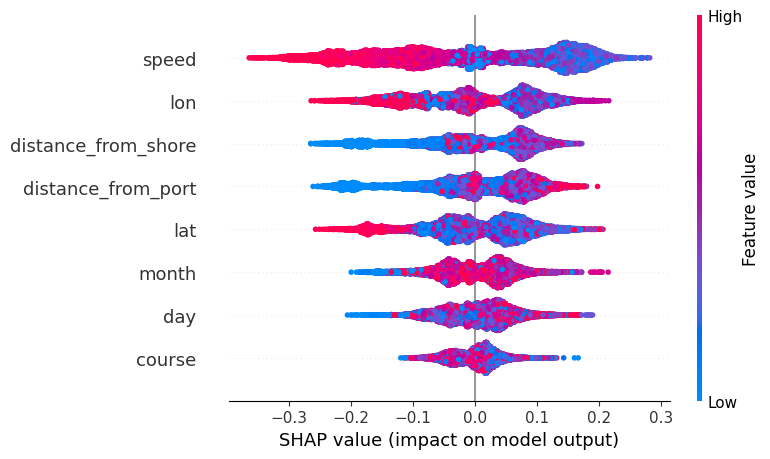

In [71]:
shap.summary_plot(
    shap_values_class_1,
    X_test_scaled_df,
    max_display=8
)

In [66]:
print(shap_values_class_1.shape)
print(X_test_scaled_df.shape)

(26742, 8)
(26742, 8)


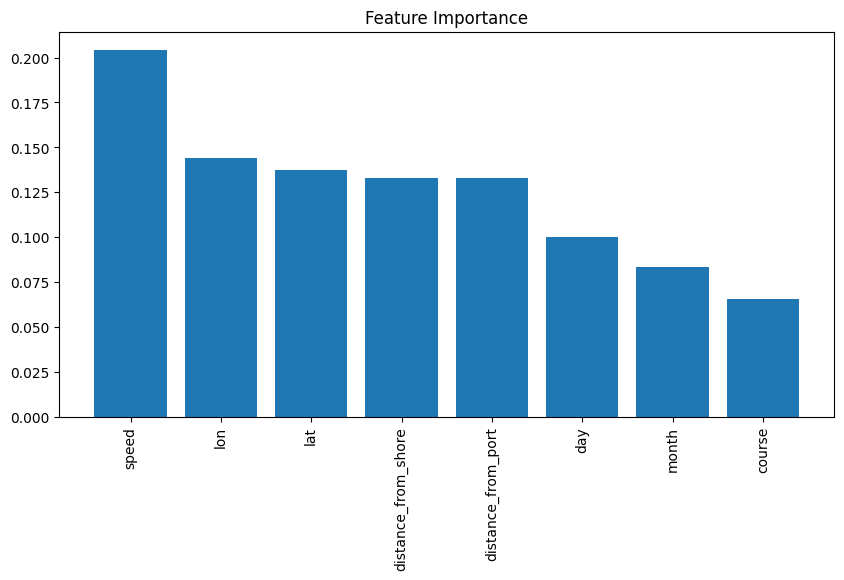

In [67]:
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.show()

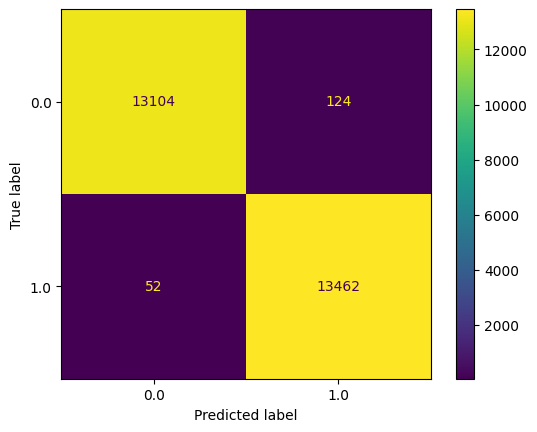

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test)

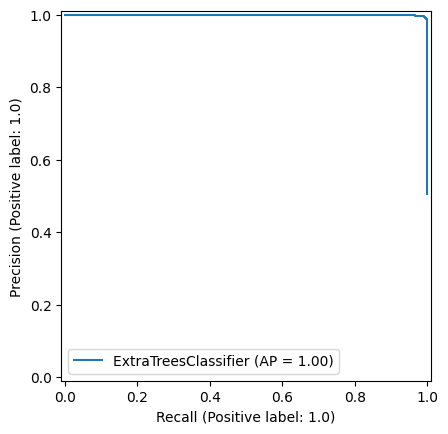

In [69]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(best_model, X_test_scaled, y_test)